هنا تكتب كود استكشاف البيانات (عرض أولي للصور، تحليل التوزيعات، إلخ).

Total images: 201838
Categories: category
dress     59104
top       48834
skirt     35129
pants     31644
jacket    27127
Name: count, dtype: int64


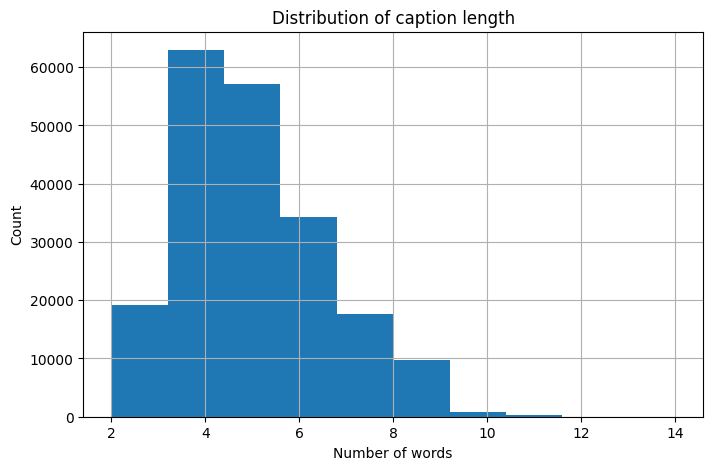

Top 20 most common words:
[('black', 60143), ('dress', 50111), ('multicolor', 45026), ('blue', 38502), ('skirt', 34787), ('jacket', 18087), ('top', 17465), ('shirt', 15466), ('white', 15309), ('lace', 10814), ('sleeve', 10414), ('maxi', 10159), ('gray', 10147), ('pants', 9926), ('print', 9860), ('midi', 8897), ('trousers', 7962), ('neck', 7926), ('floral', 7752), ('red', 7691)]


In [1]:
# File: explore_raw_data.ipynb

import os
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

# -------------------------------------------------
# Config
# -------------------------------------------------
labels_dir = "../data/raw/labels"

# -------------------------------------------------
# Utils
# -------------------------------------------------
def clean_caption(text):
    text = text.lower()
    text = text.replace("-", " ")
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# -------------------------------------------------
# Load Labels
# -------------------------------------------------
records = []
for fname in os.listdir(labels_dir):
    if not fname.endswith("_detect_all.txt"):
        continue
    category, split, *_ = fname.split("_")
    df = pd.read_csv(
        os.path.join(labels_dir, fname),
        sep="\t",
        names=["image_path", "score", "caption"],
        dtype={"image_path": str}
    )
    for _, row in df.iterrows():
        records.append({
            "image_path": row["image_path"],
            "caption": clean_caption(row["caption"]),
            "category": category,
            "split": split
        })

df_labels = pd.DataFrame(records)

print("Total images:", len(df_labels))
print("Categories:", df_labels["category"].value_counts())

# -------------------------------------------------
# Caption analysis
# -------------------------------------------------
df_labels['caption_len'] = df_labels['caption'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
df_labels['caption_len'].hist(bins=10)
plt.title("Distribution of caption length")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.show()

# Most common words
all_words = " ".join(df_labels['caption']).split()
word_counts = Counter(all_words)
print("Top 20 most common words:")
print(word_counts.most_common(20))
